In [12]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("heart.csv")

# Display basic info
print(df.head())
print(df.info())
print(df.describe())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
<class '

In [13]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [15]:
# Fill numeric missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
print(df.nunique())

id          920
age          50
sex           2
dataset       4
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64


In [17]:
# Convert to binary
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Ensure valid values
df = df[df['num'].isin([0,1])]

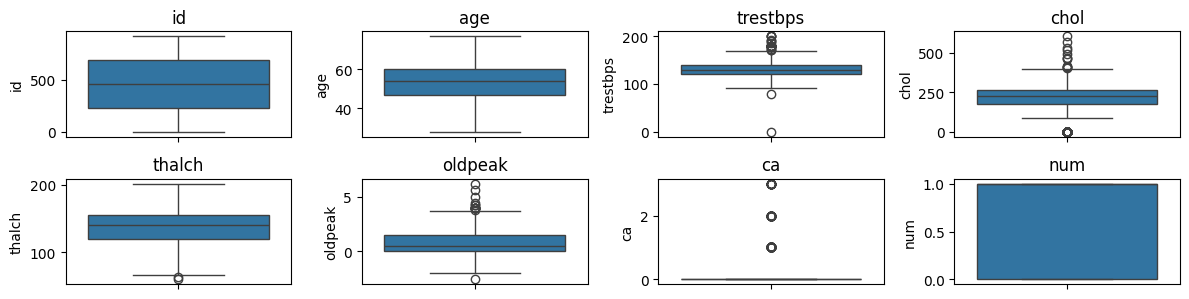

In [18]:
plt.figure(figsize=(12,6))

for i, col in enumerate(df.select_dtypes(include=np.number).columns, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
print(df.shape)

(920, 16)


In [20]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Apply on important columns
for col in ['age', 'trestbps', 'chol', 'thalch']:
    df = remove_outliers(df, col)

In [21]:
df['chol_log'] = np.log(df['chol'])

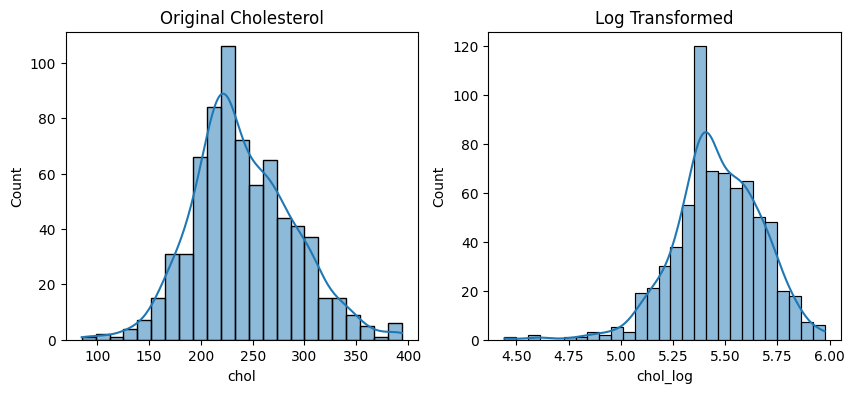

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['chol'], kde=True)
plt.title("Original Cholesterol")

plt.subplot(1,2,2)
sns.histplot(df['chol_log'], kde=True)
plt.title("Log Transformed")

plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age_scaled','chol_scaled']] = scaler.fit_transform(df[['age','chol']])

In [24]:
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  chol_log  age_scaled  chol_scaled  
0       fixed defect    0  5.451038    1.071558    -0.165371  
1             normal    1  5.655992    1.491361   

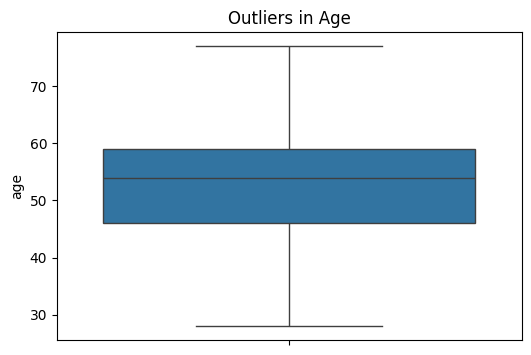

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['age'])
plt.title("Outliers in Age")
plt.show()

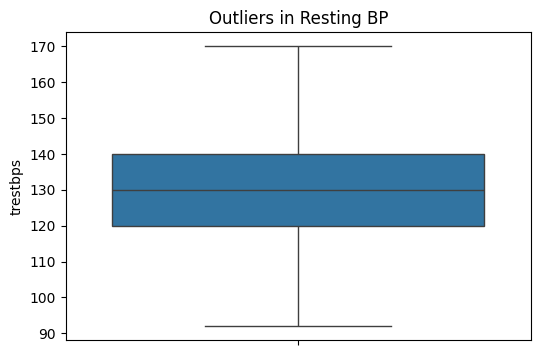

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['trestbps'])
plt.title("Outliers in Resting BP")
plt.show()

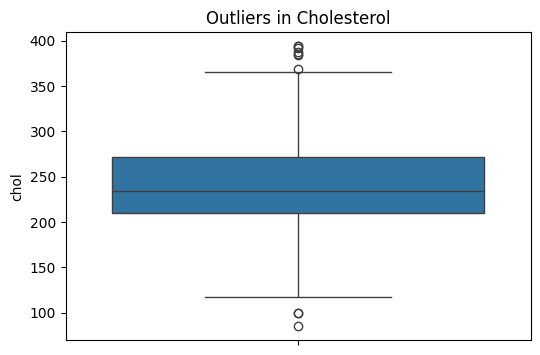

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['chol'])
plt.title("Outliers in Cholesterol")
plt.show()

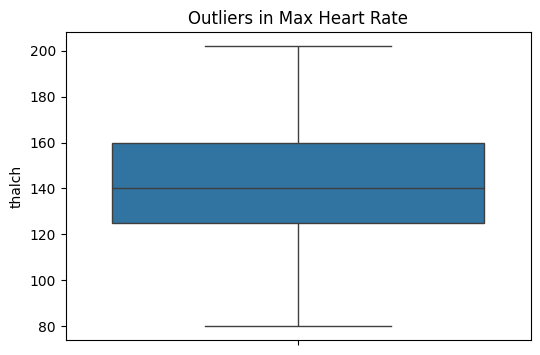

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['thalch'])
plt.title("Outliers in Max Heart Rate")
plt.show()

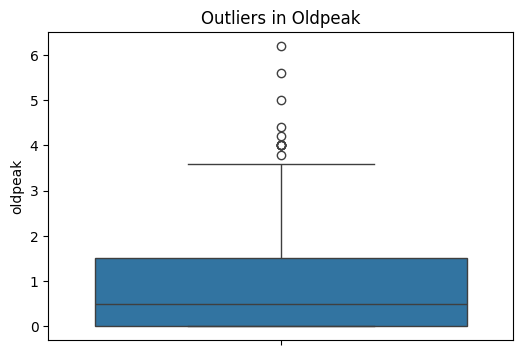

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['oldpeak'])
plt.title("Outliers in Oldpeak")
plt.show()

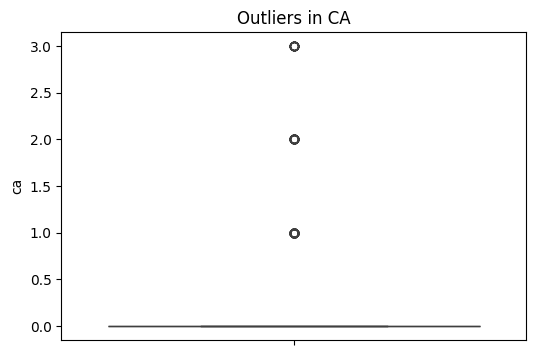

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['ca'])
plt.title("Outliers in CA")
plt.show()

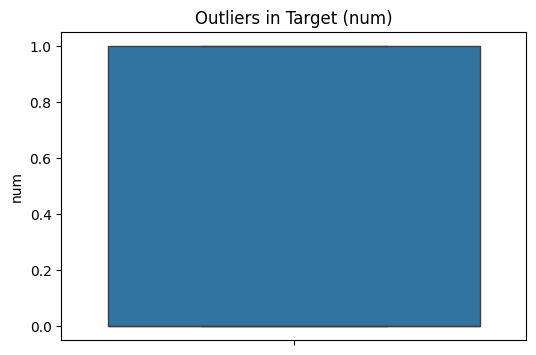

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['num'])
plt.title("Outliers in Target (num)")
plt.show()
plt.show()